In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

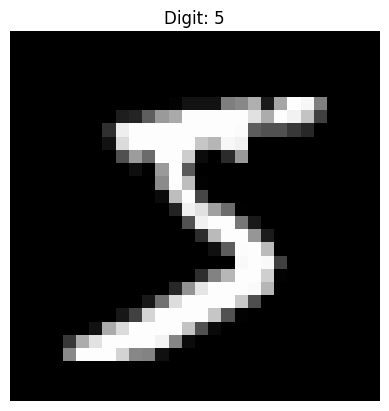

In [5]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Digit: {y_train[0]}")
plt.axis("off")
plt.show()

In [7]:
model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(128, activation="relu"),

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(10, activation="softmax")
])

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9806 - loss: 0.0617 - val_accuracy: 0.9753 - val_loss: 0.0991
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9790 - loss: 0.0663 - val_accuracy: 0.9767 - val_loss: 0.0931
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9801 - loss: 0.0623 - val_accuracy: 0.9757 - val_loss: 0.0958
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9801 - loss: 0.0615 - val_accuracy: 0.9761 - val_loss: 0.1043
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9808 - loss: 0.0601 - val_accuracy: 0.9771 - val_loss: 0.0977
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9803 - loss: 0.0633 - val_accuracy: 0.9760 - val_loss: 0.0985
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9820 - loss: 0.0574 - val_accuracy: 0.9766 - val_loss: 0.0995
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9808 -

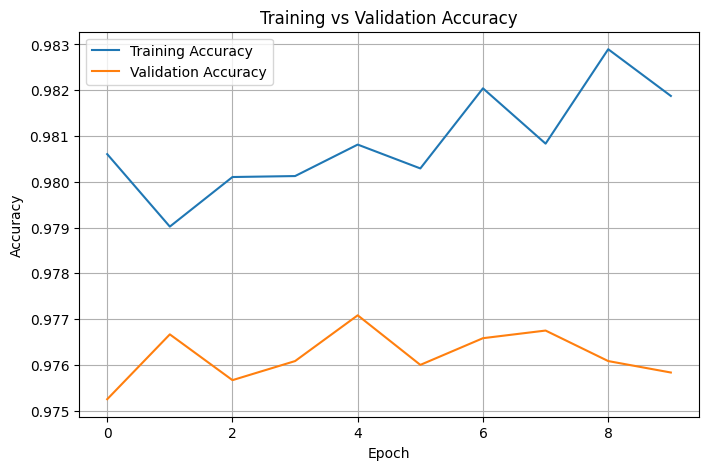

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

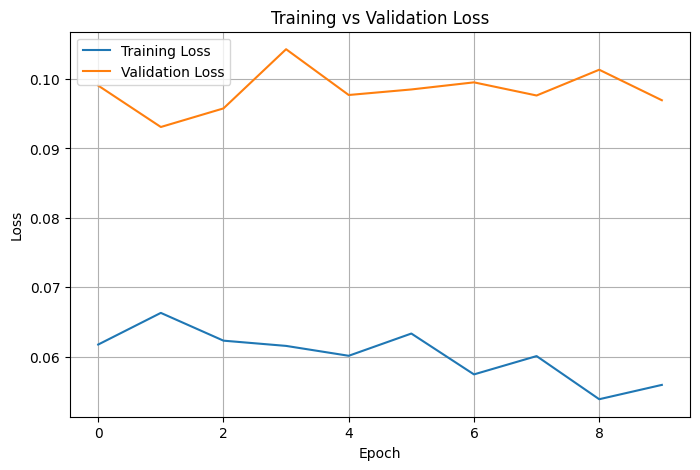

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()
plt.show()

In [16]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9778 - loss: 0.0989
Test Loss: 0.09891535341739655
Test Accuracy: 0.9778000116348267


In [17]:
model.save("mnist_digit_model.keras")

In [18]:
import os

print(os.path.exists("mnist_digit_model.keras"))

True


In [20]:
from tensorflow.keras.models import load_model

saved_model = load_model("mnist_digit_model.keras")

In [21]:
saved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [23]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [24]:
predicted_labels = np.argmax(predictions, axis=1)

In [26]:
wrong_indices = np.where(predicted_labels != y_test)[0]

print("Wrong predictions:", len(wrong_indices))

Wrong predictions: 222


In [27]:
predicted_labels != y_test

array([False, False, False, ..., False, False, False], shape=(10000,))

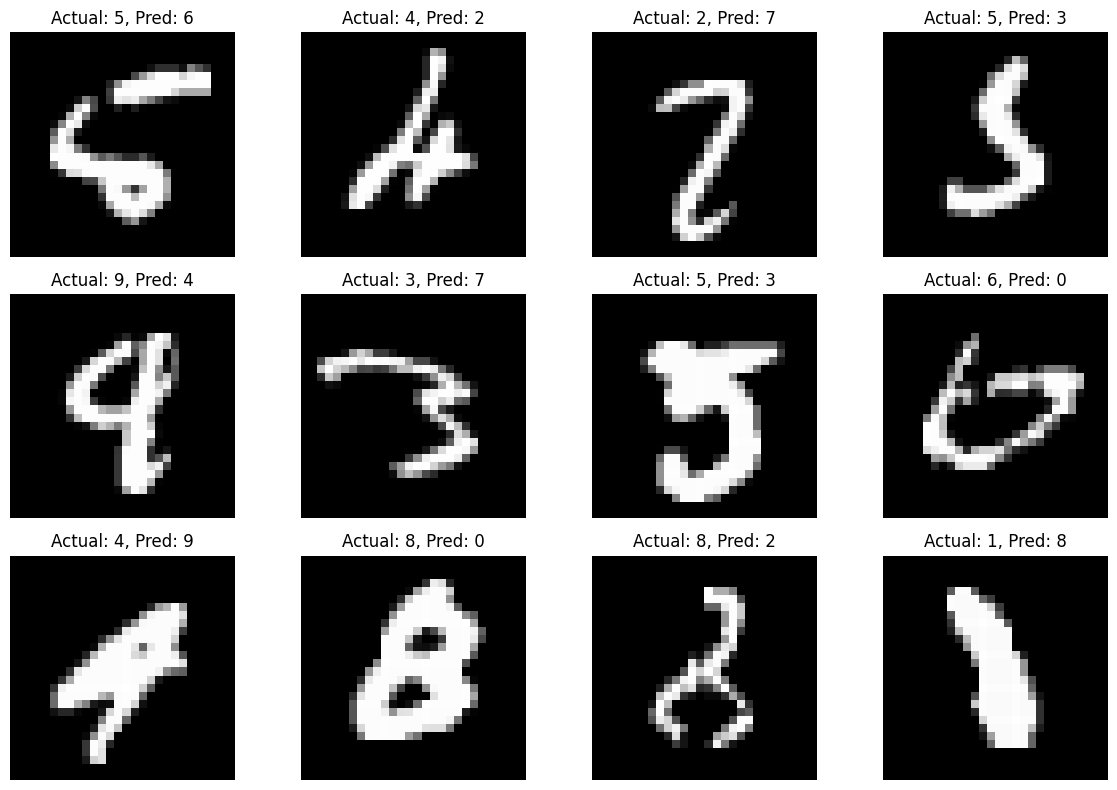

In [28]:
plt.figure(figsize=(12, 8))

for i, index in enumerate(wrong_indices[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[index], cmap="gray")

    plt.title(
        f"Actual: {y_test[index]}, Pred: {predicted_labels[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

image load successfully
image size (1152, 648)


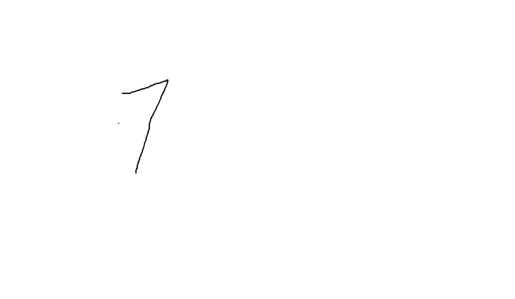

In [59]:
from PIL import Image
import matplotlib.pyplot as plt
img=Image.open("my_digit.png")

print("image load successfully")
print("image size",img.size)

plt.imshow(img,cmap="gray")
plt.axis("off")
plt.show()

In [60]:
# aeh code kabhi kabhi galat result deta hai esliye dusro code jo is 
# cell ke  nichi likha hai vo right output deta hai
 

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
img = Image.open("my_digit.png").convert("L")
img = img.resize((28, 28))
img_array = np.array(img)
img_array = img_array.astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_array)
digit = np.argmax(prediction)
print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Digit: 2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Digit: 7


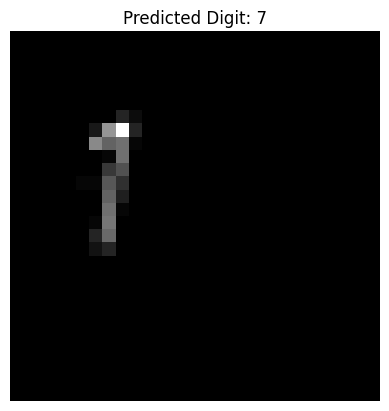

In [57]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("my_digit.png").convert("L")

img = img.resize((28, 28))

img_array = np.array(img)

img_array = img_array.astype("float32") / 255.0

# Agar background white aur digit black hai
img_array = 1 - img_array

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

digit = np.argmax(prediction, axis=1)[0]

print("Predicted Digit:", digit)

plt.imshow(img_array[0], cmap="gray")
plt.title(f"Predicted Digit: {digit}")
plt.axis("off")
plt.show()